In [11]:
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor

In [12]:
df = pd.read_csv("DATASET - Sheet1.csv")

In [13]:
encoders = {}
for col in ['CROP TYPE','SOIL TYPE','REGION','TEMPERATURE','WEATHER CONDITION']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

In [14]:
X = df.drop('WATER REQUIREMENT', axis=1)
y = df['WATER REQUIREMENT']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [16]:
model = XGBRegressor()
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [17]:
pickle.dump(model, open("xgb_model.pkl","wb"))

In [18]:
print("✅ XGB model saved")

✅ XGB model saved


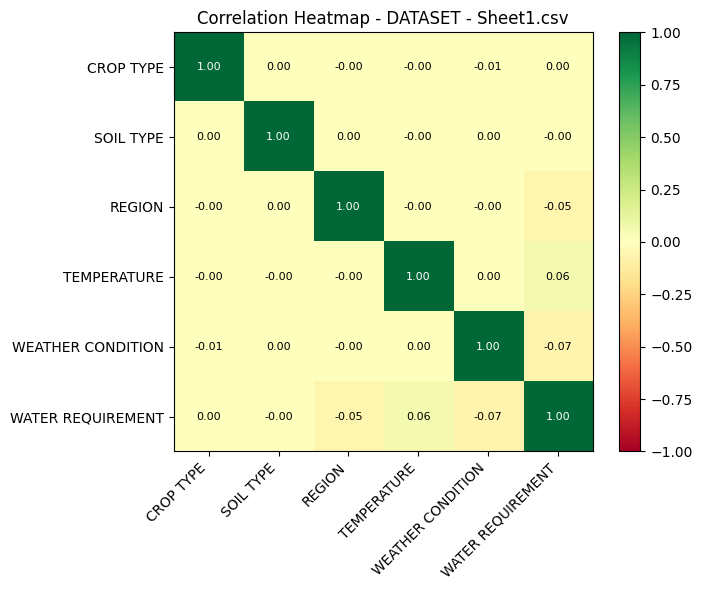

Saved: heatmaps/DATASET - Sheet1_heatmap.png


In [1]:
# Correlation heatmap (only DATASET - Sheet1.csv)
import os
import pandas as pd
import matplotlib.pyplot as plt

csv_path = 'DATASET - Sheet1.csv'
os.makedirs('heatmaps', exist_ok=True)

df_hm = pd.read_csv(csv_path)
# Convert categorical columns to numeric codes only for correlation plotting
for col in df_hm.select_dtypes(include='object').columns:
    df_hm[col] = pd.factorize(df_hm[col].astype(str).str.strip().str.upper())[0]

corr = df_hm.corr(numeric_only=True)
if corr.empty:
    raise ValueError('No valid columns found for correlation heatmap')

plt.figure(figsize=(8, 6))
im = plt.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.index)), corr.index)
plt.title(f'Correlation Heatmap - {csv_path}')
plt.colorbar(im, fraction=0.046, pad=0.04)
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        val = corr.iloc[i, j]
        txt_color = 'white' if abs(val) > 0.5 else 'black'
        plt.text(j, i, f'{val:.2f}', ha='center', va='center', color=txt_color, fontsize=8)
plt.tight_layout()
out = 'heatmaps/DATASET - Sheet1_heatmap.png'
plt.savefig(out, dpi=180)
plt.show()
print(f'Saved: {out}')
